# AntMaze-Large: Training Curves

Training metrics for 6 imitation learning algorithms (3 causal + 3 naive):
- **GAIL** (causal vs naive): 500 PPO rounds, 20 episodes/round
- **SQIL** (causal vs naive): 2M timesteps, SAC-based
- **IQ-Learn** (causal vs naive): 2M timesteps, SAC-based

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.dpi": 150,
})

PLOTS_DIR = '/home/et2842/causal/causalrl/examples/experiments/plots/antmaze-large'

# Colors: warm orange for Causal, ocean blue for Naive
C_CAUSAL = '#E07A24'
C_NAIVE  = '#2E86AB'

def smooth(y, window=10):
    """Simple moving average."""
    if len(y) < window:
        return y
    cumsum = np.cumsum(np.insert(y, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / window

## Data (extracted from training notebook outputs)

In [2]:
# ============================================================
# GAIL  (logged every 10 rounds, 500 total)
# ============================================================
gail_iters = np.arange(10, 501, 10)

cgail_return = np.array([
    -464.00,-496.80,-514.37,-397.62,-401.19,-445.66,-437.43,-379.75,-372.95,-447.12,
    -376.88,-349.48,-376.63,-389.45,-373.35,-364.77,-378.09,-347.34,-340.88,-322.20,
    -362.20,-380.66,-369.89,-358.11,-415.66,-414.85,-375.71,-342.17,-326.82,-358.58,
    -362.95,-354.99,-357.29,-346.84,-328.81,-338.09,-353.57,-351.16,-356.30,-344.44,
    -360.68,-349.90,-341.49,-340.45,-349.57,-342.28,-358.35,-320.15,-337.43,-345.80,
])

cgail_dloss = np.array([
    0.121,0.168,0.228,0.353,0.354,0.348,0.437,0.454,0.476,0.472,
    0.573,0.559,0.621,0.676,0.647,0.683,0.690,0.701,0.618,0.672,
    0.690,0.729,0.760,0.735,0.703,0.712,0.739,0.732,0.766,0.737,
    0.794,0.794,0.792,0.747,0.838,0.825,0.785,0.906,0.848,0.877,
    0.915,0.900,0.892,0.995,0.979,0.963,0.912,0.937,0.873,0.960,
])

cgail_actor_loss = np.array([
    -0.123,-0.118,-0.114,-0.110,-0.109,-0.108,-0.108,-0.110,-0.105,-0.102,
    -0.105,-0.096,-0.099,-0.103,-0.090,-0.098,-0.091,-0.085,-0.083,-0.086,
    -0.085,-0.088,-0.091,-0.084,-0.081,-0.062,-0.067,-0.057,-0.064,-0.060,
    -0.040,-0.077,-0.027,-0.037,-0.079,-0.049,-0.044,-0.035,-0.050,-0.042,
    -0.037,-0.017,-0.055,-0.027,-0.015,-0.045,-0.035,-0.041,-0.067,-0.027,
])

ngail_return = np.array([
    -449.27,-450.50,-421.32,-402.40,-436.55,-424.71,-370.08,-395.70,-400.73,-397.70,
    -400.79,-390.21,-388.06,-348.34,-324.12,-354.91,-407.55,-404.13,-377.43,-381.15,
    -359.20,-373.07,-407.96,-400.53,-340.87,-351.93,-390.72,-344.91,-326.40,-343.18,
    -372.80,-341.48,-351.15,-348.45,-376.55,-368.21,-347.46,-319.61,-357.27,-370.43,
    -318.12,-301.95,-333.91,-345.93,-309.92,-308.59,-357.08,-341.69,-359.03,-341.77,
])

ngail_dloss = np.array([
    0.143,0.178,0.207,0.316,0.325,0.347,0.382,0.350,0.381,0.441,
    0.517,0.553,0.589,0.622,0.657,0.664,0.661,0.690,0.730,0.707,
    0.771,0.788,0.793,0.790,0.843,0.883,0.883,0.873,0.867,0.865,
    0.828,0.916,0.938,0.957,0.915,0.934,0.917,0.978,0.947,0.926,
    0.978,0.956,0.954,0.961,0.973,0.948,0.940,0.969,0.916,0.987,
])

ngail_actor_loss = np.array([
    -0.124,-0.118,-0.112,-0.109,-0.108,-0.107,-0.108,-0.108,-0.109,-0.107,
    -0.108,-0.106,-0.107,-0.102,-0.104,-0.103,-0.102,-0.089,-0.094,-0.086,
    -0.088,-0.096,-0.072,-0.063,-0.071,-0.077,-0.046,-0.049,-0.040,-0.068,
    -0.017,-0.070,-0.022,-0.041,-0.028,-0.045,-0.020,-0.034,-0.026,-0.047,
    -0.022,-0.046,-0.039,-0.049,-0.087,-0.007,-0.014, 0.010,-0.020, 0.008,
])

In [3]:
# ============================================================
# SQIL  (logged every 50 episodes)
# ============================================================

csqil_ts = np.array([
    50000,100000,150000,200000,250000,300000,350000,400000,450000,499764,
    549764,598996,648784,698147,747582,797257,846493,895405,944821,991805,
    1038021,1082564,1132030,1180820,1227350,1275125,1321799,1371061,1418131,1465213,
    1511133,1557390,1604412,1647329,1694583,1738396,1783276,1828321,1873897,1919235,
    1964666,
])
csqil_eval = np.array([
    -441.35,-407.76,-415.27,-391.47,-366.16,-362.09,-358.34,-350.62,-325.94,-339.33,
    -319.79,-298.83,-341.65,-297.19,-291.19,-315.66,-350.97,-329.47,-342.49,-278.73,
    -232.59,-327.05,-336.49,-319.65,-273.20,-284.94,-272.82,-317.80,-266.33,-235.77,
    -245.09,-270.76,-293.43,-321.02,-308.34,-246.76,-283.21,-299.65,-248.98,-267.48,
    -278.19,
])
csqil_train = np.array([
    -610.22,-147.10,-156.24,-246.61,-465.53,-270.27,-382.84,-279.97,-488.86,-354.56,
    -473.19,-241.22,-566.70,-273.18,-191.57,-117.61,-215.77,-363.42,-189.65,-262.55,
    -354.34,-627.13,-405.13,-325.32,-198.85,-317.29,-229.98,-377.67,-335.64,-316.59,
    -345.58,-201.71,-376.79,-158.66,-263.71,-245.60,-475.32,-385.31,-415.37,-192.55,
    -318.47,
])
csqil_alpha = np.array([
    0.0072,0.0089,0.0103,0.0120,0.0125,0.0131,0.0144,0.0149,0.0154,0.0166,
    0.0186,0.0194,0.0207,0.0218,0.0225,0.0236,0.0238,0.0242,0.0246,0.0252,
    0.0259,0.0259,0.0261,0.0266,0.0266,0.0268,0.0271,0.0271,0.0277,0.0279,
    0.0282,0.0280,0.0280,0.0282,0.0279,0.0280,0.0281,0.0280,0.0281,0.0279,
    0.0278,
])

nsqil_ts = np.array([
    50000,100000,150000,200000,250000,299793,347997,396328,445656,493666,
    541823,590621,638391,686894,736580,785076,833834,883438,931642,978621,
    1026734,1075608,1124279,1173219,1221928,1270300,1319885,1369531,1418566,1467172,
    1516100,1565164,1613622,1662233,1711591,1760736,1810149,1859208,1907861,1956358,
])
nsqil_eval = np.array([
    -405.98,-365.28,-325.97,-332.38,-359.78,-324.83,-353.01,-321.18,-259.56,-291.08,
    -337.53,-272.14,-355.60,-366.20,-318.56,-380.30,-352.20,-296.03,-272.33,-324.27,
    -269.78,-336.74,-289.98,-356.69,-358.00,-371.99,-347.49,-368.27,-354.82,-300.59,
    -367.44,-304.23,-370.39,-461.16,-330.64,-326.30,-330.45,-338.10,-347.62,-325.44,
])
nsqil_train = np.array([
    -515.93,-540.60,-337.37,-366.75,-323.54,-372.76,-411.34,-160.90,-308.94,-362.83,
    -249.11,-422.25,-441.27,-260.03,-345.80,-457.91,-472.21,-218.30,-544.94,-293.32,
    -261.19,-243.19,-392.57,-359.29,-413.25,-300.55,-517.82,-644.49,-124.53,-238.20,
    -247.42,-569.02,-402.13,-519.05,-294.85,-256.37,-245.50,-364.30,-317.73,-421.69,
])
nsqil_alpha = np.array([
    0.0186,0.0153,0.0190,0.0197,0.0219,0.0214,0.0226,0.0236,0.0250,0.0257,
    0.0282,0.0284,0.0294,0.0296,0.0308,0.0312,0.0319,0.0313,0.0323,0.0314,
    0.0324,0.0317,0.0318,0.0310,0.0309,0.0297,0.0299,0.0297,0.0301,0.0298,
    0.0290,0.0290,0.0282,0.0281,0.0278,0.0283,0.0285,0.0285,0.0288,0.0282,
])

In [4]:
# ============================================================
# IQ-Learn  (logged every 50 episodes)
# ============================================================

ciq_ts = np.array([
    50000,100000,150000,200000,250000,300000,350000,400000,450000,498980,
    548403,598403,647663,697166,746554,796554,845960,895387,942454,990403,
    1040270,1088929,1135325,1182643,1229577,1277032,1323623,1372848,1422848,1472352,
    1521136,1570132,1618015,1667146,1713724,1759427,1805041,1852775,1898155,1943934,
    1989389,
])
ciq_eval = np.array([
    -435.94,-411.84,-387.19,-359.56,-357.46,-346.76,-368.17,-349.41,-302.00,-312.74,
    -283.91,-313.92,-312.07,-351.76,-322.56,-454.01,-324.27,-290.88,-289.29,-322.10,
    -399.24,-315.69,-334.49,-294.01,-302.95,-351.26,-324.72,-467.79,-428.44,-324.24,
    -317.30,-286.88,-309.81,-284.02,-281.99,-254.31,-255.26,-256.98,-262.57,-272.74,
    -276.52,
])
ciq_train = np.array([
    -288.92,-427.75,-323.27,-188.55,-372.19,-366.96,-195.29,-475.50,-333.27,-345.69,
    -574.18,-328.33,-563.00,-300.96,-298.92,-467.39,-300.26,-447.15,-195.46,-456.73,
    -467.32,-371.64,-464.26,-141.84,-451.52,-304.66,-170.65,-432.86,-502.06,-310.40,
    -301.56,-336.61,-425.86,-364.76,-133.01,-217.14,-374.98,-318.98,-462.23,-347.23,
    -226.55,
])
ciq_alpha = np.array([
    0.0168,0.0255,0.0253,0.0277,0.0295,0.0325,0.0355,0.0348,0.0382,0.0409,
    0.0417,0.0452,0.0478,0.0490,0.0500,0.0500,0.0531,0.0519,0.0518,0.0555,
    0.0507,0.0496,0.0497,0.0500,0.0493,0.0508,0.0525,0.0527,0.0511,0.0520,
    0.0519,0.0531,0.0537,0.0536,0.0534,0.0535,0.0528,0.0530,0.0542,0.0547,
    0.0547,
])

niq_ts = np.array([
    50000,100000,150000,200000,250000,300000,350000,400000,449896,499386,
    548938,598528,647883,697299,744733,792986,842117,890037,938201,985429,
    1032445,1081435,1129006,1176688,1223781,1270647,1319504,1366791,1414110,1461184,
    1506773,1552822,1599118,1645112,1691219,1736770,1782949,1828958,1876739,1922388,
    1970035,
])
niq_eval = np.array([
    -439.88,-409.97,-373.81,-362.13,-348.93,-347.26,-338.86,-312.39,-323.73,-330.41,
    -298.58,-279.10,-296.23,-299.55,-308.27,-301.36,-338.62,-274.44,-274.09,-309.90,
    -317.04,-263.86,-287.27,-322.84,-307.91,-257.60,-233.34,-311.69,-290.13,-288.39,
    -287.18,-306.96,-291.22,-235.37,-277.15,-271.56,-307.22,-253.92,-273.77,-294.77,
    -296.16,
])
niq_train = np.array([
    -134.53,-567.14,-617.41,-659.15,-213.56,-431.81,-86.86,-207.27,-421.57,-253.00,
    -252.22,-506.75,-129.54,-163.85,-138.15,-263.06,-268.06,-277.27,-202.13,-389.92,
    -291.99,-156.33,-228.01,-480.21,-374.88,-363.39,-224.03,-330.59,-368.65,-188.30,
    -452.19,-227.29,-422.16,-485.34,-216.74,-404.40,-312.33,-348.32,-362.77,-197.45,
    -438.58,
])
niq_alpha = np.array([
    0.0147,0.0209,0.0252,0.0278,0.0304,0.0325,0.0339,0.0370,0.0397,0.0407,
    0.0449,0.0479,0.0525,0.0533,0.0539,0.0556,0.0566,0.0564,0.0576,0.0579,
    0.0603,0.0604,0.0623,0.0636,0.0634,0.0637,0.0633,0.0647,0.0652,0.0645,
    0.0645,0.0646,0.0651,0.0652,0.0642,0.0640,0.0630,0.0629,0.0629,0.0621,
    0.0621,
])

---
## 1. GAIL Training Curves

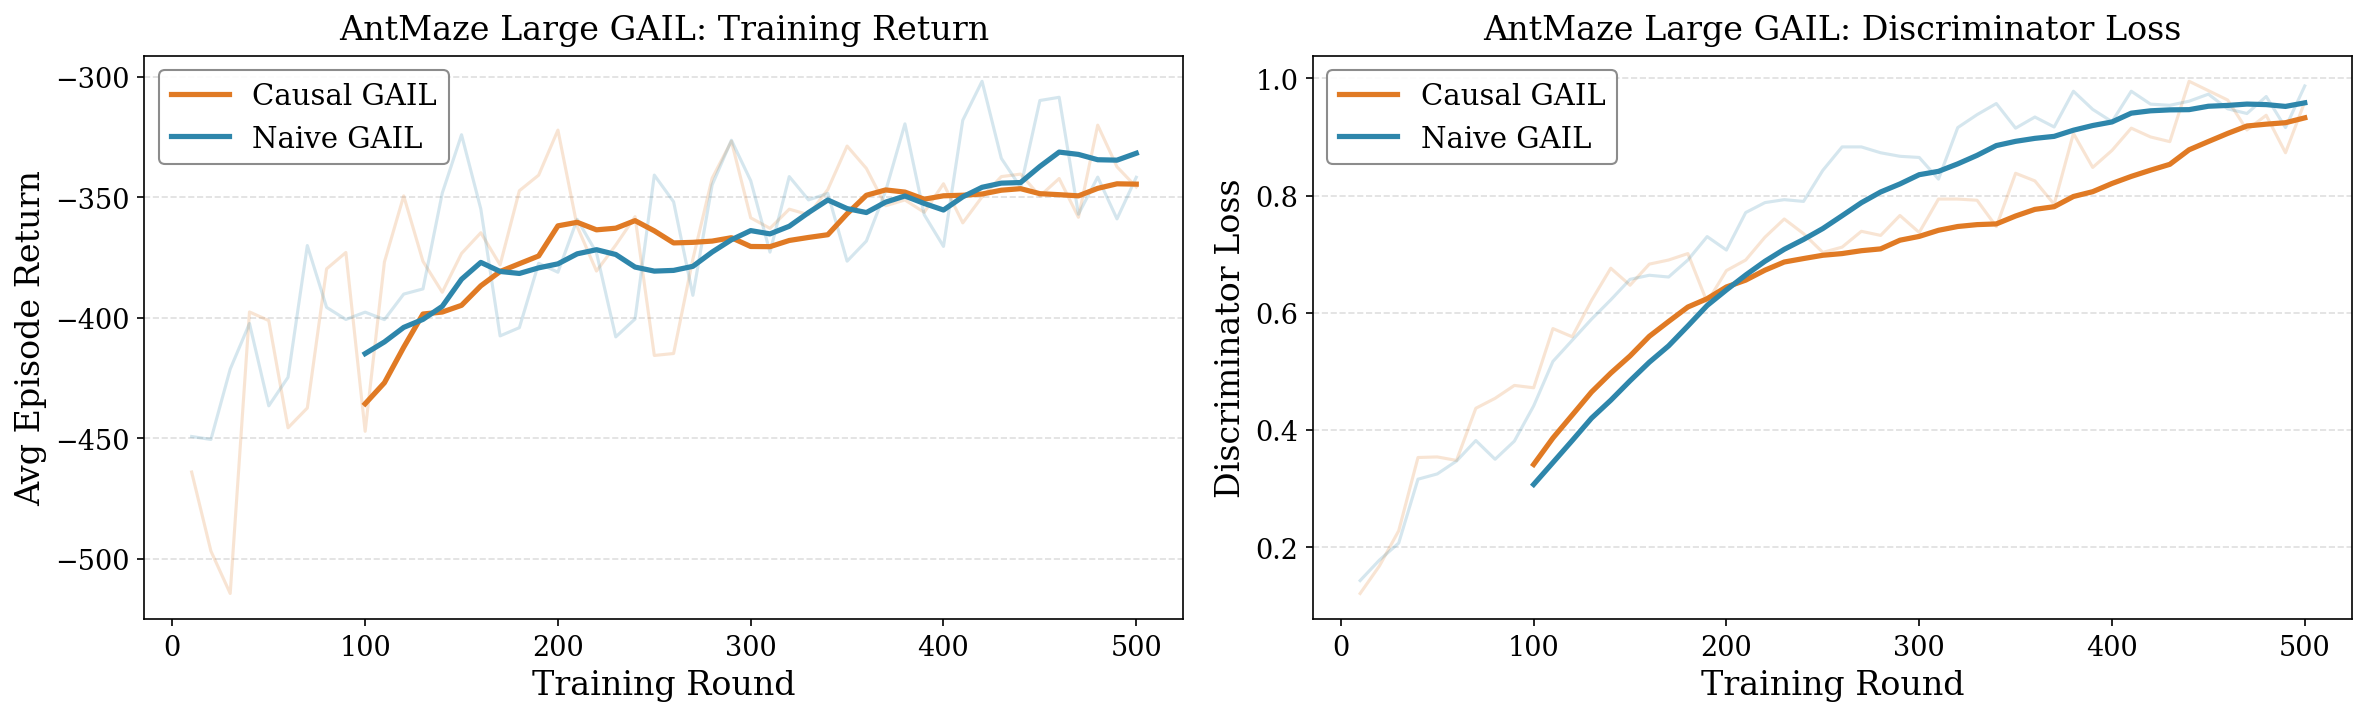

In [5]:
W = 10

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(gail_iters, cgail_return, alpha=0.2, color=C_CAUSAL)
ax.plot(gail_iters, ngail_return, alpha=0.2, color=C_NAIVE)
ax.plot(gail_iters[W-1:], smooth(cgail_return, W), linewidth=2.5, color=C_CAUSAL, label='Causal GAIL')
ax.plot(gail_iters[W-1:], smooth(ngail_return, W), linewidth=2.5, color=C_NAIVE, label='Naive GAIL')
ax.set_xlabel('Training Round')
ax.set_ylabel('Avg Episode Return')
ax.set_title('AntMaze Large GAIL: Training Return', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

ax = axes[1]
ax.plot(gail_iters, cgail_dloss, alpha=0.2, color=C_CAUSAL)
ax.plot(gail_iters, ngail_dloss, alpha=0.2, color=C_NAIVE)
ax.plot(gail_iters[W-1:], smooth(cgail_dloss, W), linewidth=2.5, color=C_CAUSAL, label='Causal GAIL')
ax.plot(gail_iters[W-1:], smooth(ngail_dloss, W), linewidth=2.5, color=C_NAIVE, label='Naive GAIL')
ax.set_xlabel('Training Round')
ax.set_ylabel('Discriminator Loss')
ax.set_title('AntMaze Large GAIL: Discriminator Loss', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antlarge_training_gail_return_dloss.pdf', dpi=300, bbox_inches='tight')
plt.show()

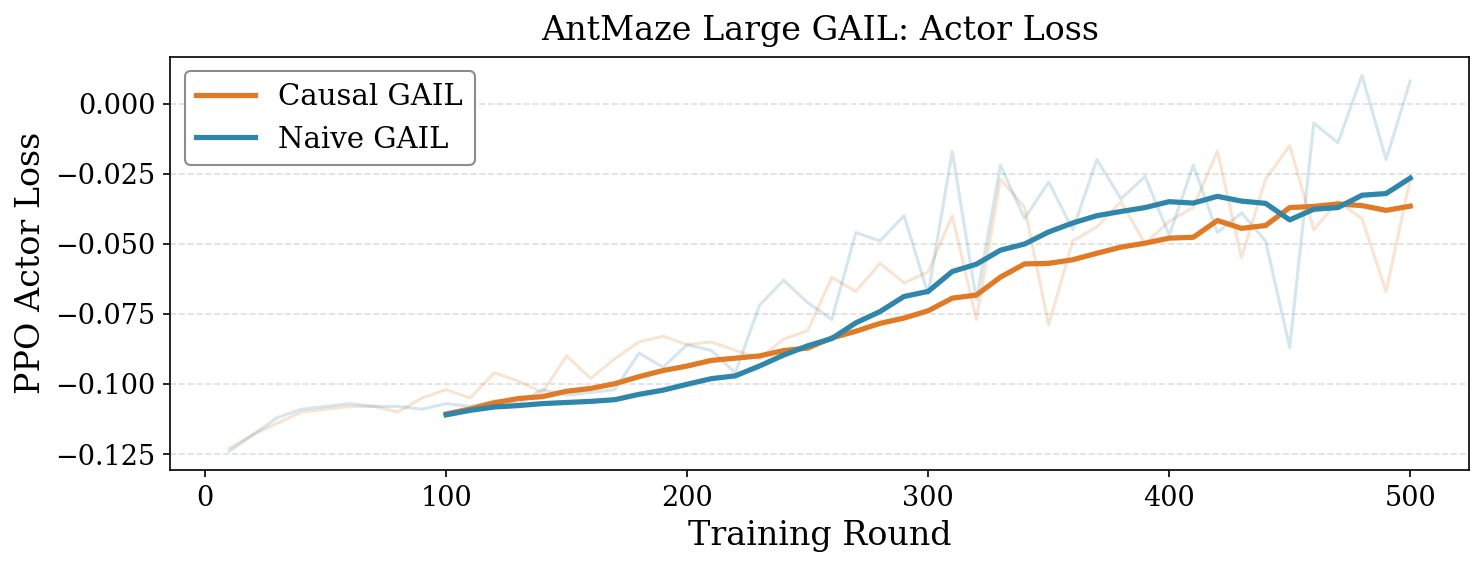

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gail_iters, cgail_actor_loss, alpha=0.2, color=C_CAUSAL)
ax.plot(gail_iters, ngail_actor_loss, alpha=0.2, color=C_NAIVE)
ax.plot(gail_iters[W-1:], smooth(cgail_actor_loss, W), linewidth=2.5, color=C_CAUSAL, label='Causal GAIL')
ax.plot(gail_iters[W-1:], smooth(ngail_actor_loss, W), linewidth=2.5, color=C_NAIVE, label='Naive GAIL')
ax.set_xlabel('Training Round')
ax.set_ylabel('PPO Actor Loss')
ax.set_title('AntMaze Large GAIL: Actor Loss', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antlarge_training_gail_actor_loss.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## 2. SQIL Training Curves

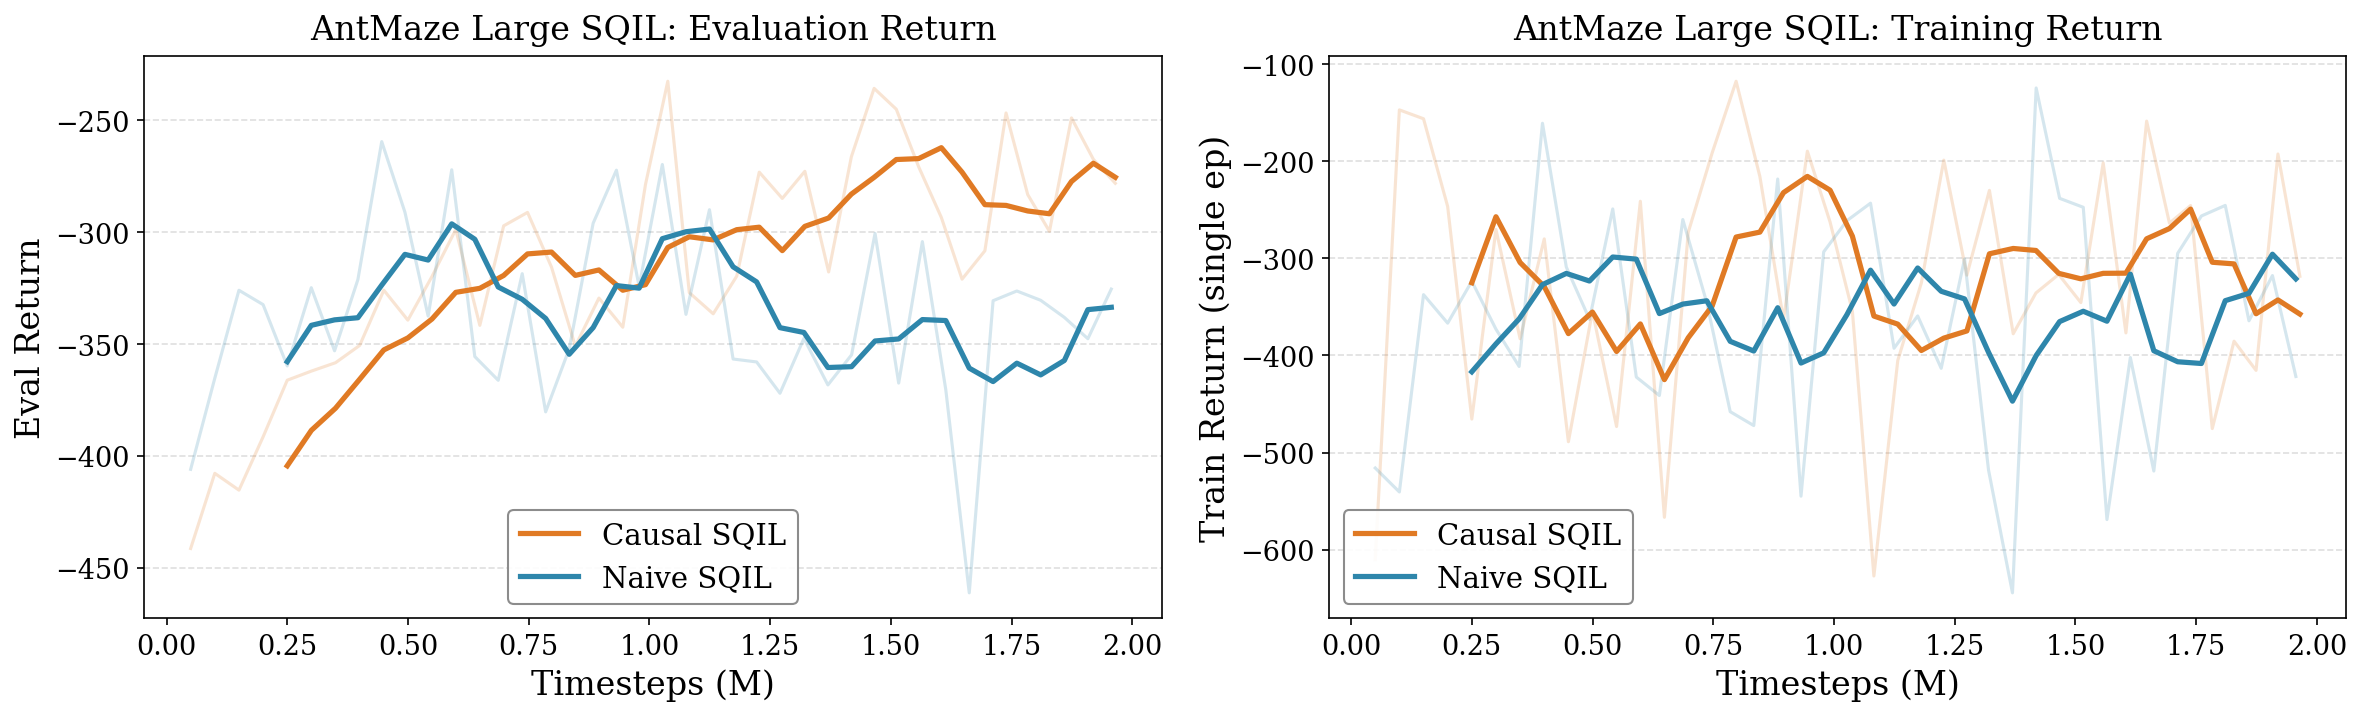

In [7]:
W_sac = 5

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(csqil_ts / 1e6, csqil_eval, alpha=0.2, color=C_CAUSAL)
ax.plot(nsqil_ts / 1e6, nsqil_eval, alpha=0.2, color=C_NAIVE)
ax.plot(csqil_ts[W_sac-1:] / 1e6, smooth(csqil_eval, W_sac), linewidth=2.5, color=C_CAUSAL, label='Causal SQIL')
ax.plot(nsqil_ts[W_sac-1:] / 1e6, smooth(nsqil_eval, W_sac), linewidth=2.5, color=C_NAIVE, label='Naive SQIL')
ax.set_xlabel('Timesteps (M)')
ax.set_ylabel('Eval Return')
ax.set_title('AntMaze Large SQIL: Evaluation Return', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

ax = axes[1]
ax.plot(csqil_ts / 1e6, csqil_train, alpha=0.2, color=C_CAUSAL)
ax.plot(nsqil_ts / 1e6, nsqil_train, alpha=0.2, color=C_NAIVE)
ax.plot(csqil_ts[W_sac-1:] / 1e6, smooth(csqil_train, W_sac), linewidth=2.5, color=C_CAUSAL, label='Causal SQIL')
ax.plot(nsqil_ts[W_sac-1:] / 1e6, smooth(nsqil_train, W_sac), linewidth=2.5, color=C_NAIVE, label='Naive SQIL')
ax.set_xlabel('Timesteps (M)')
ax.set_ylabel('Train Return (single ep)')
ax.set_title('AntMaze Large SQIL: Training Return', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antlarge_training_sqil_curves.pdf', dpi=300, bbox_inches='tight')
plt.show()

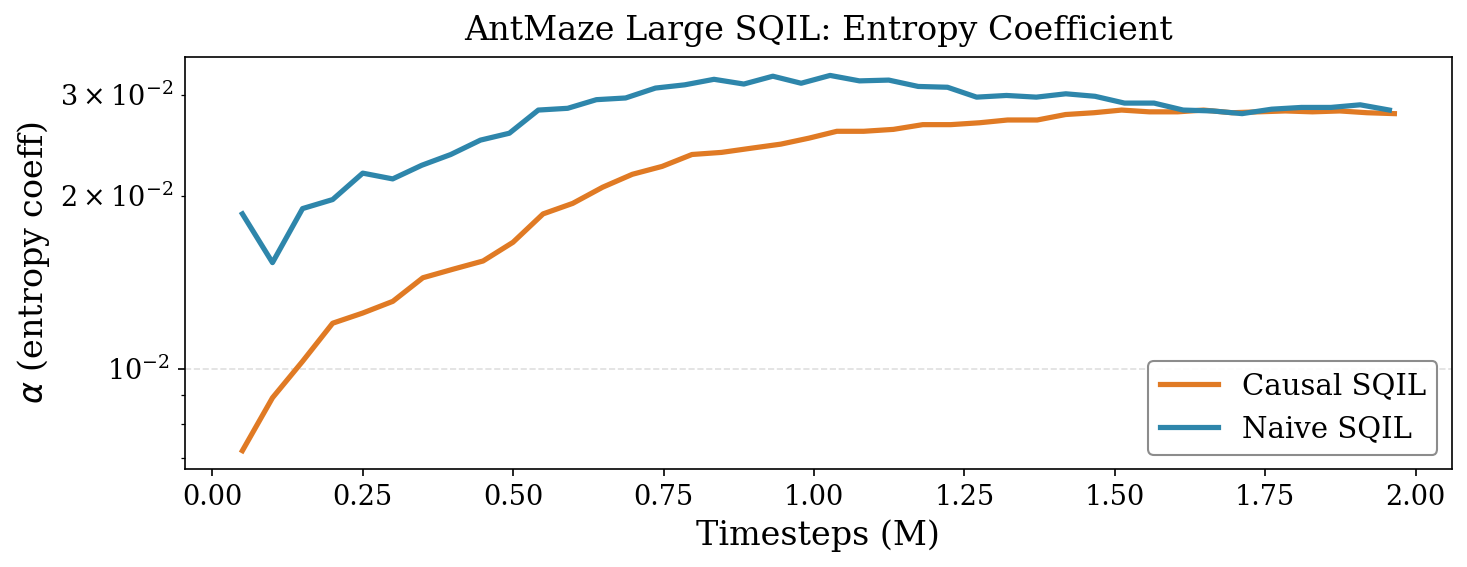

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(csqil_ts / 1e6, csqil_alpha, linewidth=2.5, color=C_CAUSAL, label='Causal SQIL')
ax.plot(nsqil_ts / 1e6, nsqil_alpha, linewidth=2.5, color=C_NAIVE, label='Naive SQIL')
ax.set_xlabel('Timesteps (M)')
ax.set_ylabel('$\\alpha$ (entropy coeff)')
ax.set_title('AntMaze Large SQIL: Entropy Coefficient', pad=8)
ax.set_yscale('log')
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antlarge_training_sqil_alpha.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## 3. IQ-Learn Training Curves

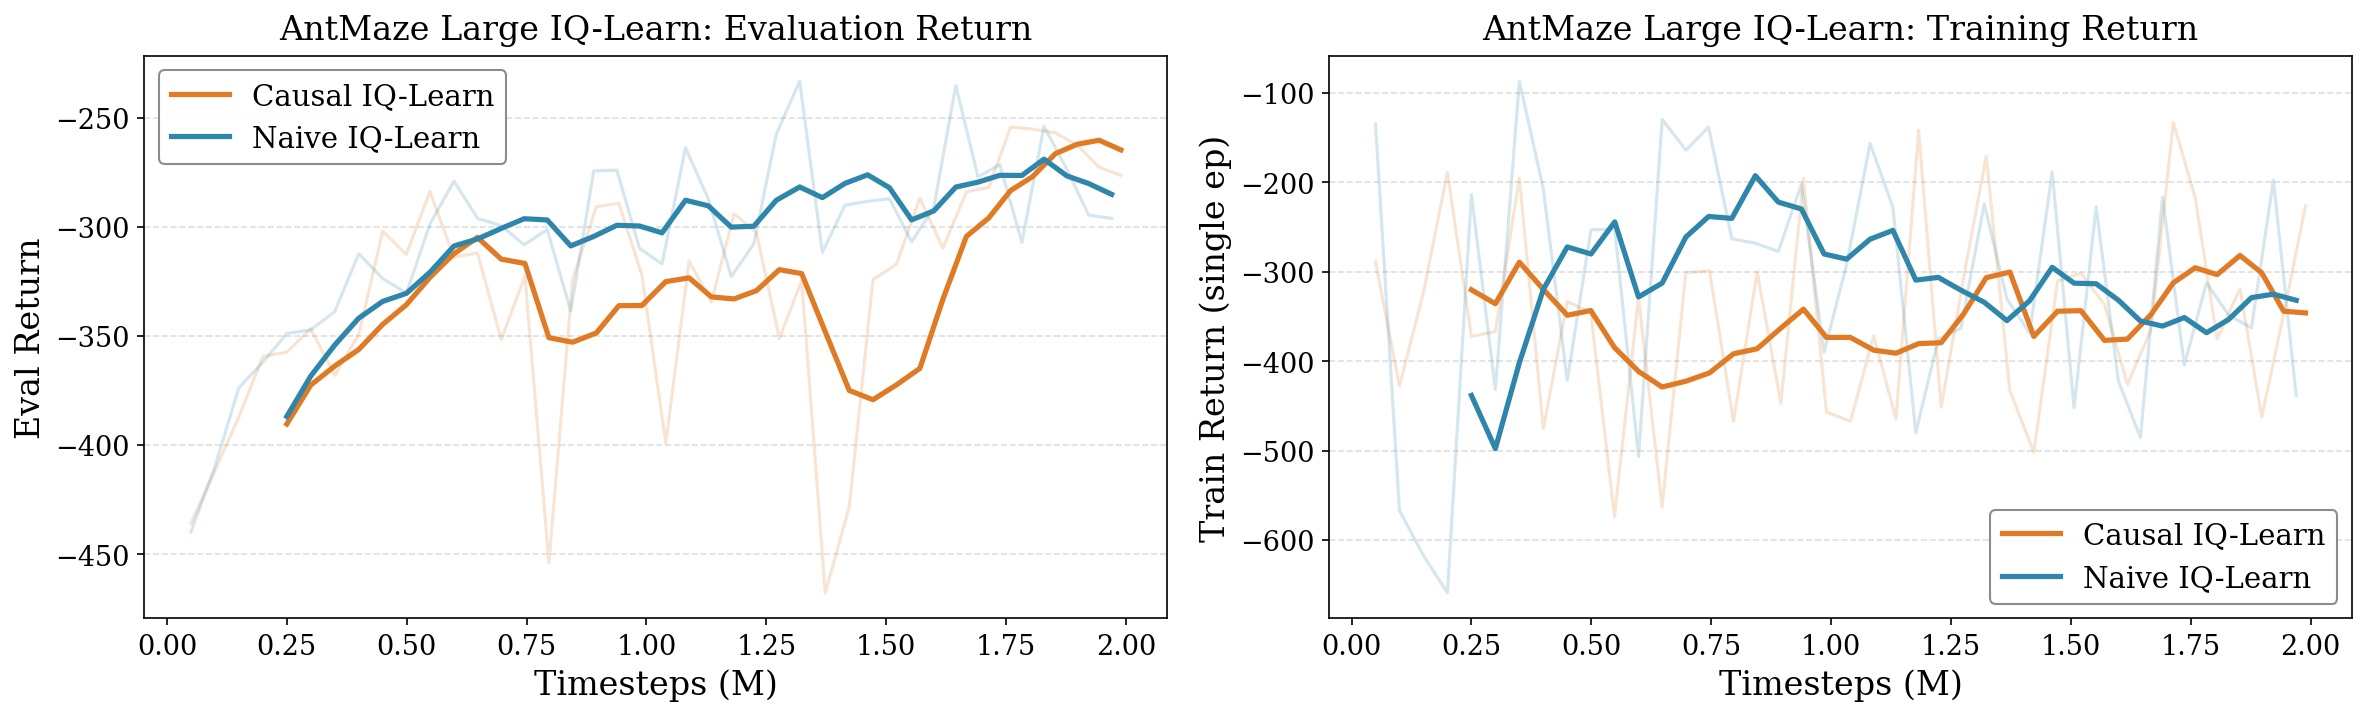

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(ciq_ts / 1e6, ciq_eval, alpha=0.2, color=C_CAUSAL)
ax.plot(niq_ts / 1e6, niq_eval, alpha=0.2, color=C_NAIVE)
ax.plot(ciq_ts[W_sac-1:] / 1e6, smooth(ciq_eval, W_sac), linewidth=2.5, color=C_CAUSAL, label='Causal IQ-Learn')
ax.plot(niq_ts[W_sac-1:] / 1e6, smooth(niq_eval, W_sac), linewidth=2.5, color=C_NAIVE, label='Naive IQ-Learn')
ax.set_xlabel('Timesteps (M)')
ax.set_ylabel('Eval Return')
ax.set_title('AntMaze Large IQ-Learn: Evaluation Return', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

ax = axes[1]
ax.plot(ciq_ts / 1e6, ciq_train, alpha=0.2, color=C_CAUSAL)
ax.plot(niq_ts / 1e6, niq_train, alpha=0.2, color=C_NAIVE)
ax.plot(ciq_ts[W_sac-1:] / 1e6, smooth(ciq_train, W_sac), linewidth=2.5, color=C_CAUSAL, label='Causal IQ-Learn')
ax.plot(niq_ts[W_sac-1:] / 1e6, smooth(niq_train, W_sac), linewidth=2.5, color=C_NAIVE, label='Naive IQ-Learn')
ax.set_xlabel('Timesteps (M)')
ax.set_ylabel('Train Return (single ep)')
ax.set_title('AntMaze Large IQ-Learn: Training Return', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antlarge_training_iqlearn_curves.pdf', dpi=300, bbox_inches='tight')
plt.show()

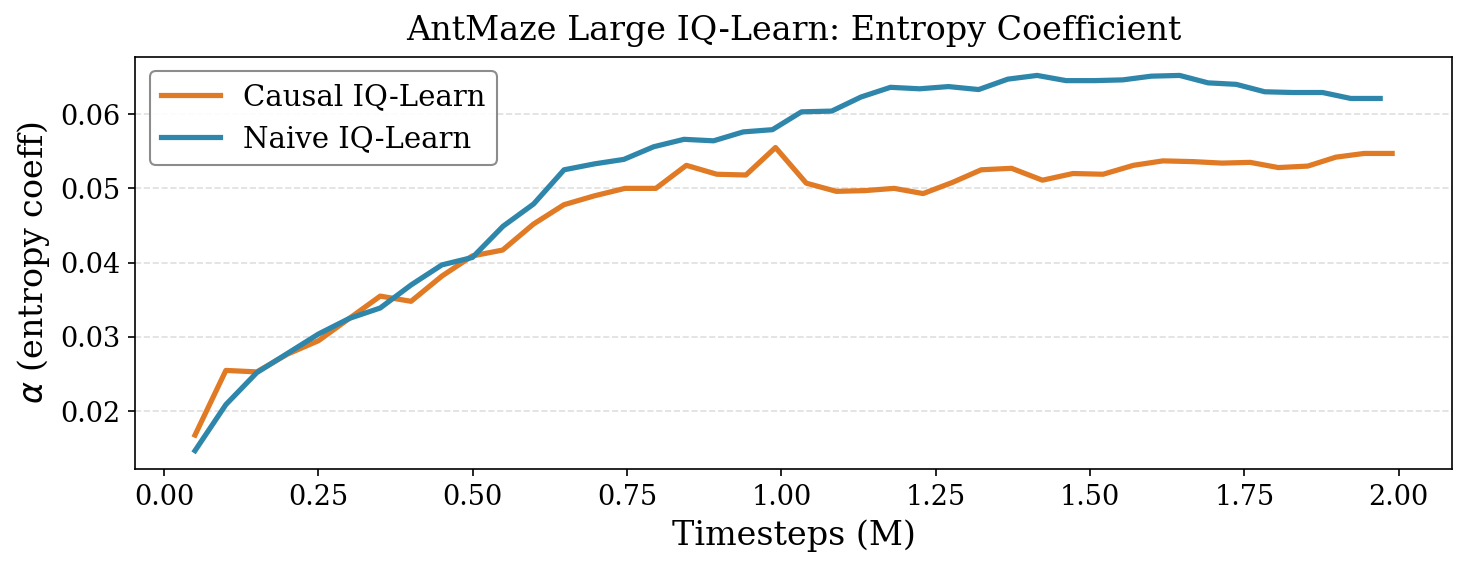

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ciq_ts / 1e6, ciq_alpha, linewidth=2.5, color=C_CAUSAL, label='Causal IQ-Learn')
ax.plot(niq_ts / 1e6, niq_alpha, linewidth=2.5, color=C_NAIVE, label='Naive IQ-Learn')
ax.set_xlabel('Timesteps (M)')
ax.set_ylabel('$\\alpha$ (entropy coeff)')
ax.set_title('AntMaze Large IQ-Learn: Entropy Coefficient', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antlarge_training_iqlearn_alpha.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## 4. Combined: All Algorithms Eval Return

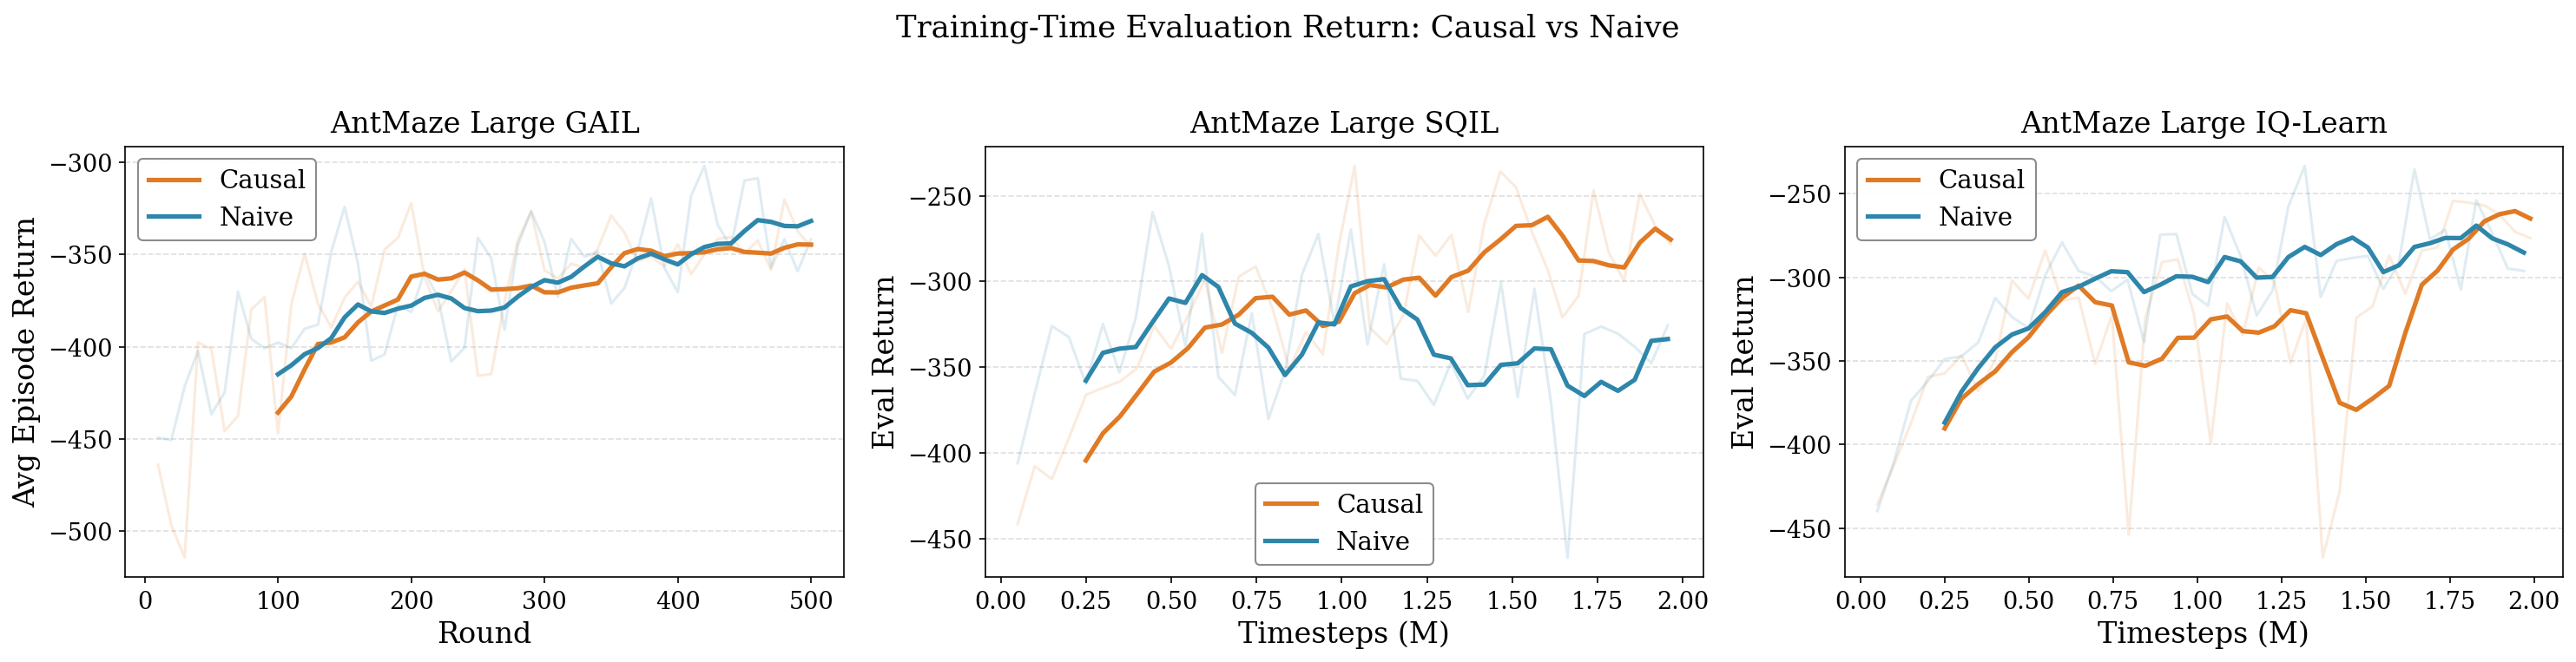

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax = axes[0]
ax.plot(gail_iters, cgail_return, alpha=0.15, color=C_CAUSAL)
ax.plot(gail_iters, ngail_return, alpha=0.15, color=C_NAIVE)
ax.plot(gail_iters[W-1:], smooth(cgail_return, W), linewidth=2.5, color=C_CAUSAL, label='Causal')
ax.plot(gail_iters[W-1:], smooth(ngail_return, W), linewidth=2.5, color=C_NAIVE, label='Naive')
ax.set_xlabel('Round')
ax.set_ylabel('Avg Episode Return')
ax.set_title('AntMaze Large GAIL', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

ax = axes[1]
ax.plot(csqil_ts / 1e6, csqil_eval, alpha=0.15, color=C_CAUSAL)
ax.plot(nsqil_ts / 1e6, nsqil_eval, alpha=0.15, color=C_NAIVE)
ax.plot(csqil_ts[W_sac-1:] / 1e6, smooth(csqil_eval, W_sac), linewidth=2.5, color=C_CAUSAL, label='Causal')
ax.plot(nsqil_ts[W_sac-1:] / 1e6, smooth(nsqil_eval, W_sac), linewidth=2.5, color=C_NAIVE, label='Naive')
ax.set_xlabel('Timesteps (M)')
ax.set_ylabel('Eval Return')
ax.set_title('AntMaze Large SQIL', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

ax = axes[2]
ax.plot(ciq_ts / 1e6, ciq_eval, alpha=0.15, color=C_CAUSAL)
ax.plot(niq_ts / 1e6, niq_eval, alpha=0.15, color=C_NAIVE)
ax.plot(ciq_ts[W_sac-1:] / 1e6, smooth(ciq_eval, W_sac), linewidth=2.5, color=C_CAUSAL, label='Causal')
ax.plot(niq_ts[W_sac-1:] / 1e6, smooth(niq_eval, W_sac), linewidth=2.5, color=C_NAIVE, label='Naive')
ax.set_xlabel('Timesteps (M)')
ax.set_ylabel('Eval Return')
ax.set_title('AntMaze Large IQ-Learn', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.suptitle('Training-Time Evaluation Return: Causal vs Naive', fontsize=17, y=1.02)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antlarge_training_combined_eval_return.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## 5. Combined: All Causal Algorithms

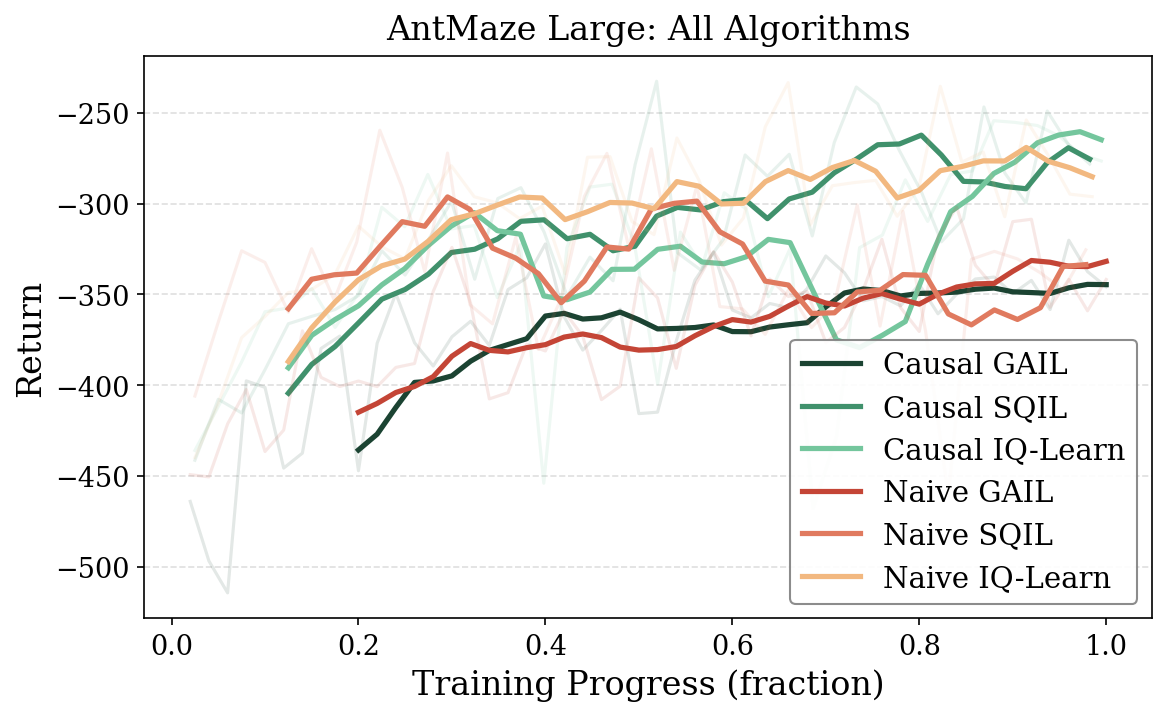

In [13]:
# Colors for multi-algorithm overlay (3 distinguishable greens)
C_GAIL = '#1B4332'    # darkest
C_SQIL = '#40916C'    # medium
C_IQL  = '#74C69D'    # lighter

# Lighter palette for naive
C_GAIL_N = "#C44536"
C_SQIL_N = "#E07A5F"
C_IQL_N  = "#F2B880"

fig, ax = plt.subplots(figsize=(8, 5))

# --- Causal (faint raw) ---
ax.plot(gail_iters / 500, cgail_return, alpha=0.12, color=C_GAIL)
ax.plot(csqil_ts / 2e6, csqil_eval, alpha=0.12, color=C_SQIL)
ax.plot(ciq_ts / 2e6, ciq_eval, alpha=0.12, color=C_IQL)

# --- Causal (smoothed) ---
ax.plot(gail_iters[W-1:] / 500, smooth(cgail_return, W),
        linewidth=2.5, color=C_GAIL, label='Causal GAIL')
ax.plot(csqil_ts[W_sac-1:] / 2e6, smooth(csqil_eval, W_sac),
        linewidth=2.5, color=C_SQIL, label='Causal SQIL')
ax.plot(ciq_ts[W_sac-1:] / 2e6, smooth(ciq_eval, W_sac),
        linewidth=2.5, color=C_IQL, label='Causal IQ-Learn')

# --- Naive (faint raw) ---
ax.plot(gail_iters / 500, ngail_return, alpha=0.12, color=C_GAIL_N)
ax.plot(nsqil_ts / 2e6, nsqil_eval, alpha=0.12, color=C_SQIL_N)
ax.plot(niq_ts / 2e6, niq_eval, alpha=0.12, color=C_IQL_N)

# --- Naive (smoothed) ---
ax.plot(gail_iters[W-1:] / 500, smooth(ngail_return, W),
        linewidth=2.5, color=C_GAIL_N, label='Naive GAIL')
ax.plot(nsqil_ts[W_sac-1:] / 2e6, smooth(nsqil_eval, W_sac),
        linewidth=2.5, color=C_SQIL_N, label='Naive SQIL')
ax.plot(niq_ts[W_sac-1:] / 2e6, smooth(niq_eval, W_sac),
        linewidth=2.5, color=C_IQL_N, label='Naive IQ-Learn')

ax.set_xlabel('Training Progress (fraction)')
ax.set_ylabel('Return')
ax.set_title('AntMaze Large: All Algorithms', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antlarge_training_all_algorithms_progress.pdf',
            dpi=300, bbox_inches='tight')
plt.show()